# Plots for Thesis

In [2]:
from ModelFitting.AllModelFunctions import *
from functions import divide_colormap, ZAMS, evolutionary_track, find_ZAMS_index, time_intervals
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import UnivariateSpline

### Global variables

In [3]:
object_names = ['4U1538-52', '4U1700-37', 'Cen X-3', 'LMC X-4', 'SMC X-1', 'Vela X-1']

TITLE = 18
LABEL = 12
LEGEND = 8
TEXTBOX = 8
ALPHA = 0.25

WAVLABEL = r"$\lambda$ ($\AA$)"
FLUXLABEL = r"Norm. Flux"


Thesis_Folder = "/mnt/c/Users/luukv/OneDrive/Masterproject/Thesis/Plots/"

### Import data

In [4]:
# Import UVES spectra
spectra = {}
for HMXB in object_names:
    spectra[HMXB] = import_spectra(object_name_to_save_name(HMXB))

# Import models
models = import_models_quickload('Milkyway')

# Table with all HMXB parameters
AllParams = pd.read_excel("/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject/tables/Parameters/AllParam.xlsx")

Spectrum for LMCX_4 is FLUX REDUCED


### Model example

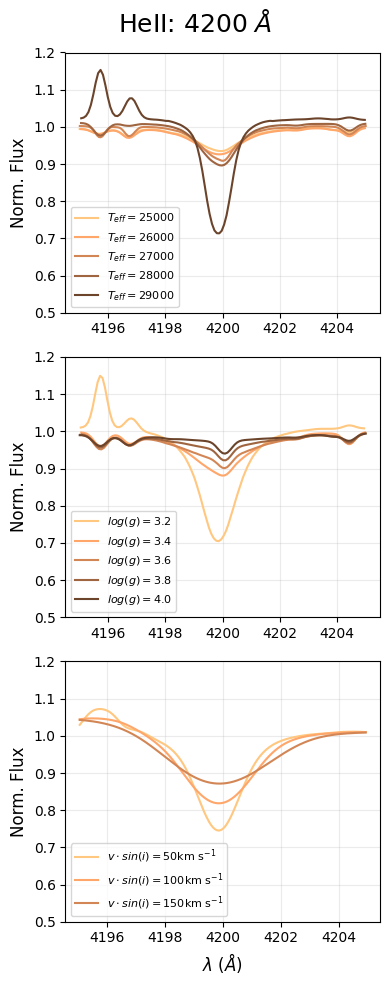

In [5]:
# Make a selection of models
models_Teff = models_in_interval(models, T1=25000, T2=31000, log_g1=3.0, log_g2=3.0)
models_logg = models_in_interval(models, T1=30000, T2=30000, log_g1=2.4, log_g2=4.0)
model_vsini = models_in_interval(models, T1=30000, T2=30000, log_g1=3.2, log_g2=3.2)['T30000logg3.2']
# Get list of colors for plots
colors = divide_colormap(6, colormap_name="copper_r")


fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(4, 10))

for i, (key, model) in enumerate(models_Teff.items()):
    wav, flux = extract_spectrum_within_range(np.array(model['WAVELENGTH']), np.array(model['FLUX']), 4200 - 5, 4200 + 5)
    Teff, logg = extract_temperature_and_gravity(key)
    axes[0].plot(wav, flux, label=r"$T_{eff}=$"+f"{Teff}", color=colors[i])
axes[0].legend(fontsize=LEGEND)
axes[0].set_ylabel(FLUXLABEL, fontsize=LABEL)
# axes[0].set_title(r"$T_{eff}$", fontsize=LABEL)


for i, (key, model) in enumerate(models_logg.items()):
    wav, flux = extract_spectrum_within_range(np.array(model['WAVELENGTH']), np.array(model['FLUX']), 4200 - 5, 4200 + 5)
    Teff, logg = extract_temperature_and_gravity(key)
    axes[1].plot(wav, flux, label=r"$log(g)=$"+f"{logg}", color=colors[i])
axes[1].legend(fontsize=LEGEND)
axes[1].set_ylabel(FLUXLABEL, fontsize=LABEL)
# axes[1].set_title(r"$log(g)$", fontsize=LABEL)


wav, flux = extract_spectrum_within_range(np.array(model_vsini['WAVELENGTH']), np.array(model_vsini['FLUX']), 4200 - 5, 4200 + 5)
for i, vsini in enumerate(np.arange(50, 200, 50)):
    # Apply doppler broadening
    wav, flux = pyasl.equidistantInterpolation(wav, flux, "2x")
    flux = pyasl.rotBroad(wav, flux, 0.0, vsini)
    axes[2].plot(wav, flux, label=r"$v\cdot sin(i)=$"+f"{vsini}"+r"km s$^{-1}$", color=colors[i])
axes[2].legend(fontsize=LEGEND, loc='lower left')
axes[2].set_ylabel(FLUXLABEL, fontsize=LABEL)
axes[2].set_xlabel(WAVLABEL, fontsize=LABEL)
# axes[2].set_title(r"$v \cdot sin(i)$", fontsize=LABEL)


for ax in axes:
    ax.grid(alpha=ALPHA)
    ax.set_ylim(0.5, 1.2)

plt.suptitle(r"HeII: $4200$ $\AA$", fontsize=TITLE)
plt.tight_layout()
plt.savefig(Thesis_Folder + "ModelExample.png")
plt.show()

### HRD with HMXB

In [6]:
def first_unique_indexes(lst):
    first_occurrence = {}
    for index, value in enumerate(lst):
        if value not in first_occurrence:
            first_occurrence[value] = index
    return list(first_occurrence.values())

# Set the metallicity value
ZY_values = [(0.02, 0.284), (0.03, 0.302), (0.04, 0.321)]
Z = ZY_values[0][0]
Y = ZY_values[0][1]

# Determine place of Zero-Age main sequence
L_ZAMS, T_ZAMS = ZAMS(Z=Z, Y=Y)

M_values = [16, 18, 20, 24, 28, 30, 35, 40, 50, 55, 60, 65, 70, 80, 90, 95, 100]
M_values = [14, 20, 24, 35]
M_values = ['{:07.3f}'.format(m) for m in M_values]


L_ass_err = [AllParams['L-'] / (np.log(10) * AllParams['L']), AllParams['L+'] / (np.log(10) * AllParams['L'])]

Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
F

Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.
Folder |Z0.02Y0.284| already exists.


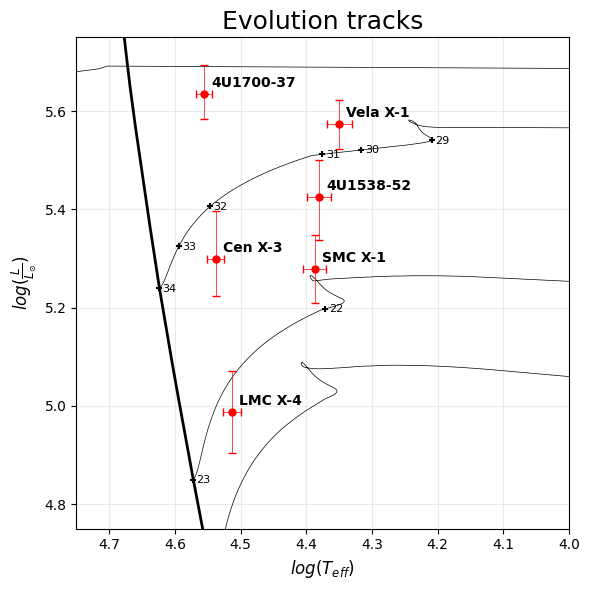

In [7]:
plt.figure(figsize=(6,6))
for M in M_values:
    df = evolutionary_track(Z=ZY_values[0][0], Y=ZY_values[0][1], M=M)

    ZAMS_index = find_ZAMS_index(df['H_CEN'].tolist())
    logL = df["LOG_L"].tolist()[ZAMS_index:]
    logT = df["LOG_TE"].tolist()[ZAMS_index:]

    logL = [float(x) for x in logL]
    logT = [float(x) for x in logT]

    plt.plot(logT, logL, label=(f'M={int(float(M))}'+r'$M_{\odot}$'), color='black', linewidth=0.5)

    M, L, T = [], [], []
    for t in time_intervals(start_point= ZAMS_index, N_iterations=df.shape[0], N_intervals=200):
        M.append(int(df['MASS'][t]))
        L.append(df['LOG_L'][t])
        T.append(df['LOG_TE'][t])
    
    unique_M = first_unique_indexes(M)
    L = [L[i] for i in unique_M]
    T = [T[i] for i in unique_M]
    M = [M[i] for i in unique_M]

    for m, l, t in zip(M, L, T):
        plt.scatter([t], [l], color='black', zorder=3, marker='+', s=20)
        plt.annotate(f'{m}', (t, l), fontsize=8, textcoords="offset points", xytext=(2.5,-2.5), ha='left') #  + r'$M_{\odot}$'

for i, label in enumerate(AllParams["id"].tolist()):
    plt.annotate(label, (np.log10(AllParams['Teff']).tolist()[i], np.log10(AllParams['L']).tolist()[i]), textcoords="offset points", xytext=(5,5), ha='left', 
                 weight='bold', fontsize=10)

plt.plot(T_ZAMS, L_ZAMS, label='ZAMS', color='black', linewidth=2)
# plt.scatter(np.log10(AllParams['Teff']), np.log10(AllParams['L']), color='black', s=20, marker='o')
plt.errorbar(np.log10(AllParams['Teff']), np.log10(AllParams['L']), yerr=L_ass_err, xerr=(AllParams['Teff_err'] / (np.log(10) * AllParams['Teff'])), color='red',
             linestyle='none', marker='o', markersize=5, capsize=3, linewidth=0.5)
plt.title(f'Evolution tracks', fontsize=TITLE)
plt.xlabel(r"$log(T_{eff})$", fontsize=LABEL)
plt.ylabel(r"$log(\frac{L}{L_{\odot}})$", fontsize=LABEL)
plt.ylim(4.75, 5.75)
plt.xlim(4.0, 4.75)
plt.grid(alpha=ALPHA)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig(Thesis_Folder + "HRD.png")
# plt.legend(fontsize=LEGEND)
plt.show()

### Normalized spectra

Import spectra

In [8]:
HOME = '/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject'
# Get all the folder names in the spectra folder
subfolders = [f.name for f in os.scandir(HOME + '/Spectra') if f.is_dir()]

# Make a dictionary of all the spectra
spectra = {}
for folder in subfolders:
    spectra[folder] = import_spectra(folder)

    if folder == '4U1700_37':
        path = '/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject/Spectra/4U1700_37/old_spectra/'
        spectra4U1700 = import_spectra(folder, folder_path2=path)
        for wav, flux in spectra4U1700:
            spectra[folder].append((wav, flux))

Spectrum for LMCX_4 is FLUX REDUCED


Spectra ranges

In [9]:
for key, spectrum in spectra.items():
    print(key)
    for wav, flux in spectrum:
        print(f"\tRange:  {round(wav[0])}\t-\t{round(wav[-1])}")

4U1538_52
	Range:  3282	-	4563
	Range:  4583	-	6687
4U1700_37
	Range:  3044	-	3917
	Range:  4583	-	6686
	Range:  6650	-	10426
	Range:  3732	-	5000
CenX_3
	Range:  4583	-	6686
	Range:  3281	-	4562
LMCX_4
	Range:  3281	-	4562
	Range:  4583	-	6686
SMCX_1
	Range:  3281	-	4562
	Range:  4583	-	6686
VelaX_1
	Range:  3528	-	9217


Normalize

In [10]:
ALL_LINES = {
        r'H$\alpha$ 6563': 6563,
        r'H$\beta$ 4861': 4861,
        r'H$\gamma$ 4340': 4340.47,
        r'H$\delta$': 4101.73,
        r'H$\epsilon$ 3970': 3970.08,
        r'H$\zeta$ 3889': 3889.06,
        r'H$\eta$ 3835': 3835.4,

        'HeI 4471.50': 4471.5,
        'HeI+II 4026.21': 4026.21,
        'HeI 3819.62': 3819.62,
        'HeI 3705.02': 3705.02,
        'HeI 3634.25': 3634.25,
        'HeI 3587.27': 3587.27,
        'HeI 4921.93': 4921.93,
        'HeI 4387.93': 4387.93,
        'HeI 4143.76': 4143.76,
        'HeI 4009.26': 4009.26,
        'HeI 4713.17': 4713.17,
        'HeI 5015.68': 5015.68,
        'HeI 5047.74': 5047.74,
        'HeI 5876': 5876,
        'HeI 4388': 4388,
        'HeI 4121': 4121,

        'HeII 5411.53': 5411.53,
        'HeII 4199.83': 4199.83,
        'HeII 4200': 4200,
        'HeII 4686': 4686,
        'HeII 4541': 4541,
        'HeII 6527': 6527,

        'SiI 4128-30': 4128,
        'SiII 4552': 4552,
        'SiIII 5739': 5739,
        'SiIII 4552': 4552,
        'SiIII 4567': 4567,
        'SiIII4574': 4574,
        'SiIV4116': 4116,
        'SiIV4212': 4212,
        'SiIV4089': 4089,
        'SiIV 4686-4504': 4695,

        'H10 3797.90': 3797.90,
        'H11 3770.63': 3770.63,
        'H12 3750.15': 3750.15,
        'H13 3734.37': 3734.37,
        'H14 3721.94': 3721.94,
        'H15 3711.97': 3711.97,
        'H16 3703.85': 3703.85,

        'NII 3995': 3995,
        'NIII 4634-40-42 emission': 4634,
        'NIII 4097': 4097,
        'NIV 4058': 4058,

        'NaI 5890': 5890,
        'NaI 5896': 5896,

        'CIII 4187':4187,

        'OII 4350': 4350,

        'MgII 4481': 4481,

        'FeII 4233': 4233}



def normalize_spectrum(wavelength, flux, plot=False):

    wavelength = np.array(wavelength)
    flux = np.array(flux)

    # Normalize the y values using min-max normalization
    y_min, y_max = np.min(flux), np.max(flux)
    flux = (flux - y_min) / (y_max - y_min)

    # Use a smoothing spline to fit the continuum
    spline = UnivariateSpline(wavelength, flux, s=0.5 * len(wavelength))  # Adjust 's' for smoothness
    continuum = spline(wavelength)

    if plot:
    # Plot the fitted continuum
        plt.figure(figsize=(10, 5))
        plt.plot(wavelength, flux, label='Original Spectrum')
        plt.plot(wavelength, continuum, label='Fitted Continuum', linestyle='--')
        plt.xlabel('Wavelength (Angstrom)')
        plt.ylabel('Flux')
        plt.title('Fitted Continuum')
        plt.grid(alpha=0.25)
        plt.legend()
        plt.show()

    # Normalize the spectrum
    normalized_flux = flux / continuum

    if max(normalized_flux) > 1.5:
        normalized_flux *= 0.5
        normalized_flux += 0.5

    if plot:
        # Plot the normalized spectrum
        plt.figure(figsize=(10, 5))
        plt.plot(wavelength, normalized_flux, label='Normalized Spectrum')
        plt.xlabel('Wavelength (Angstrom)')
        plt.ylabel('Normalized Flux')
        plt.title('Normalized UVES Spectrum')
        plt.legend()
        plt.ylim(0, 2)
        plt.grid(alpha=0.25)
        plt.show()

    return wavelength, normalized_flux

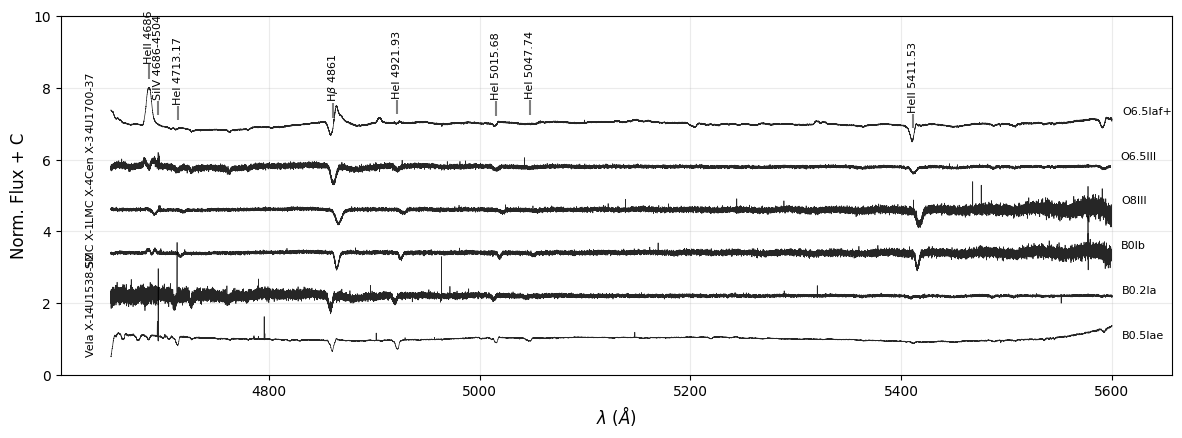

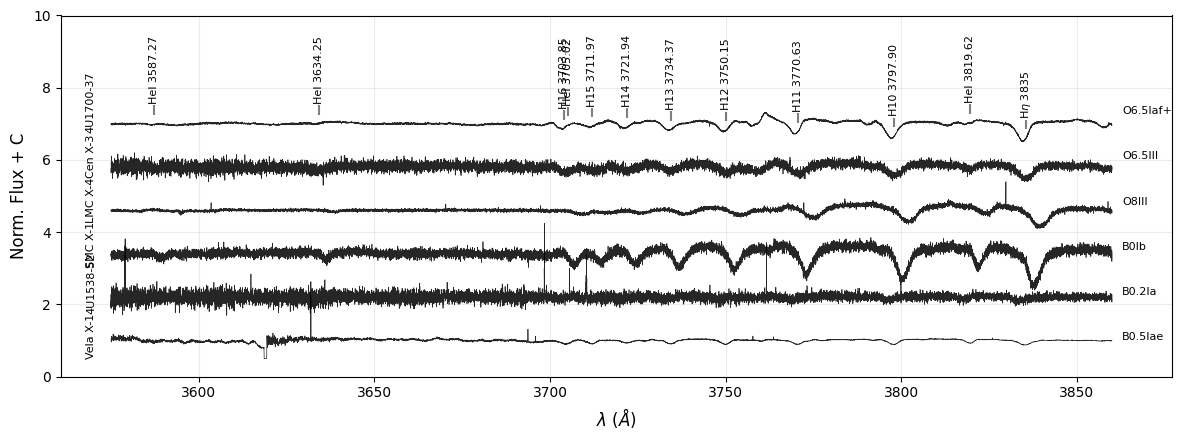

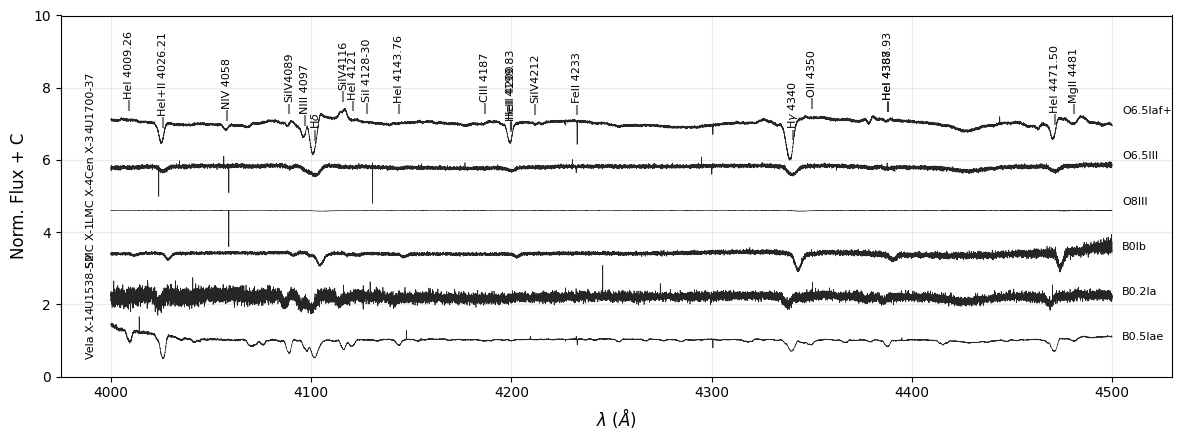

In [11]:
def plot_spectra_with_lines(spectra, ALL_LINES, wav_low, wav_high, save=False):
    object_order = ['4U1700-37', 'Cen X-3', 'LMC X-4', 'SMC X-1', '4U1538-52', 'Vela X-1']
    object_order = ['Vela X-1', '4U1538-52', 'SMC X-1', 'LMC X-4', 'Cen X-3', '4U1700-37']

    objects_done = []

    plt.figure(figsize=(12,4.5))

    for i, (name) in enumerate(object_order):
        spectra_object = spectra[object_name_to_save_name(name)]
        for wav2, flux2 in spectra_object:
            if name in objects_done:
                continue
            elif min(wav2) <= wav_low + 10 <= max(wav2):
                objects_done.append(name)
                wav, flux = wav2, flux2
                # Spectral type
                ST = AllParams.loc[AllParams.id == name, 'ST'].reset_index(drop=True).at[0]

                # Normalize spectrum
                wav, flux = extract_spectrum_within_range(wav, flux, wav_low, wav_high)
                wav, flux = normalize_spectrum(wav, flux, False)

                fraction = max(wav) - min(wav)

                # Plot spectrum
                plt.plot(wav, flux + i*1.2, color='black', alpha=0.85, linewidth=0.5)
                plt.text(wav[0] - 0.02 * fraction, i*1.25 + 0.5, name, ha='center', va='bottom', rotation=90, size=TEXTBOX)
                plt.text(wav[-1] + 0.01 * fraction, i*1.25 + 1.1, ST, ha='left', va='center', rotation=0, size=TEXTBOX)


    # The spectral lines in the range of this spectrum
    lines = spectral_lines_in_range(ALL_LINES, wav)
    wavs = [tup for tup in lines.values()]
    names = [tup for tup in lines.keys()]

    # Plot the spectral lines
    index = find_closest_wavelength_indices(wavs, wav)
    flux_low = flux[index] + i*1.25
    flux_high = flux[index] + (max(flux) / 5) + i*1.25
    plt.vlines(wavs, ymin=flux_low, ymax=flux_high, color='black', alpha=0.5)

    # Annotate each line with text vertically
    for (x, y, name) in zip(wavs, flux_high, names):
        plt.text(x, y + max(flux) / 100 + 0.02, name.replace('_', ' '), ha='center', va='bottom', rotation=90, size=TEXTBOX)

    plt.xlim(min(wav) - 0.05 * fraction, max(wav) + 0.06 * fraction)
    plt.ylim(ymin=0, ymax=i*2 - 0)
    plt.grid(alpha=ALPHA)
    plt.xlabel(WAVLABEL, fontsize=LABEL)
    plt.ylabel(FLUXLABEL + ' + C', fontsize=LABEL)
    plt.tight_layout()
    if save:
        plt.savefig(Thesis_Folder + f'spectra{round(min(wav))}_{round(max(wav))}')
    plt.show()

    return



plot_spectra_with_lines(spectra, ALL_LINES, 4650, 5600, save=True)
plot_spectra_with_lines(spectra, ALL_LINES, 3575, 3860, save=True)
plot_spectra_with_lines(spectra, ALL_LINES, 4000, 4500, save=True)

### RESULTS

RR vs MM

In [16]:
def error_fraction(A, dA, B, dB):
    C = A / B
    dC = np.sqrt((dA / B) ** 2 + (A * dB / B**2) ** 2)
    return dC


MM = (AllParams['Mopt'] / AllParams['Mhrd']).tolist()
RR = (AllParams['Reff'] / AllParams['Ropt']).tolist()

MM_high = error_fraction(A=AllParams['Mopt'], dA=AllParams['Mopt_err'], 
                         B=AllParams['Mhrd'], dB=AllParams['Mhrd_err']).tolist()
MM_low = error_fraction(A=AllParams['Mopt'], dA=AllParams['Mopt_err'], 
                         B=AllParams['Mhrd'], dB=AllParams['Mhrd_err']).tolist()


RR_high = error_fraction(A=AllParams['Reff'], dA=AllParams['Reff+'], 
                         B=AllParams['Ropt'], dB=AllParams['Ropt_err']).tolist()
RR_low = error_fraction(A=AllParams['Reff'], dA=AllParams['Reff-'], 
                         B=AllParams['Ropt'], dB=AllParams['Ropt_err']).tolist()


RR_asymmetric_err = [RR_low, RR_high]
MM_asymmetric_err = [MM_low, MM_high]

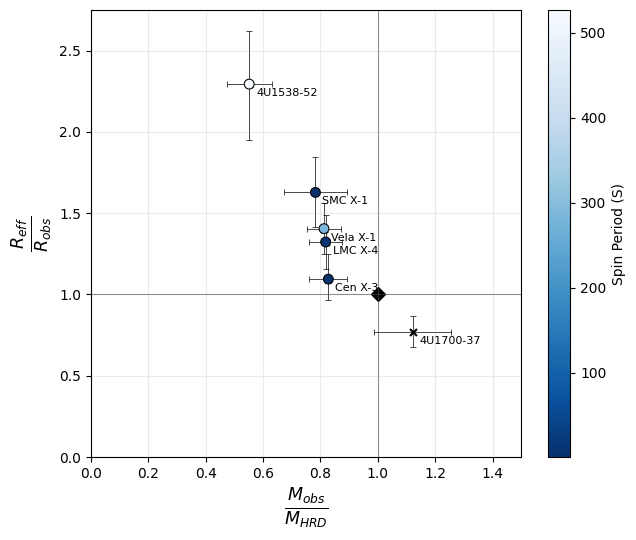

In [17]:

plt.figure(figsize=(6.5,5.5))
plt.errorbar(MM, RR, yerr=RR_asymmetric_err, xerr=MM_asymmetric_err, fmt='none', ecolor='black', capsize=2, zorder=1, elinewidth=.5, capthick=.5)
plt.scatter(MM, RR, s=25, marker='x', color='black', zorder=2)
plt.scatter(MM, RR, c=AllParams['Ps'].tolist(), cmap='Blues_r', edgecolors='black', linewidths=.75, s=50, zorder=3)
plt.colorbar(label='Spin Period (S)')  # Add color bar with label
plt.plot([0, 2], [1, 1], linestyle='-', color='black', alpha=.5, zorder=1, linewidth=.75)
plt.plot([1, 1], [0,4], linestyle='-', color='black', alpha=.5, zorder=1, linewidth=.75)
plt.scatter(1, 1, s=50, color='black', marker='D')
# Add labels to each point
for i, label in enumerate(AllParams["id"].tolist()):
    plt.annotate(label, (MM[i], RR[i]), textcoords="offset points", xytext=(5,-6.5), ha='left', va='center', fontsize=TEXTBOX)
plt.ylim(0, 2.75)
plt.xlim(0, 1.5)
plt.grid(True, alpha=ALPHA)
plt.xlabel(r"$\frac{M_{obs}}{M_{HRD}}$", fontsize=18)
plt.ylabel(r"$\frac{R_{eff}}{R_{obs}}$", fontsize=18)
plt.tight_layout()
plt.savefig(Thesis_Folder + 'RRvsMM.png')
plt.show()

R vs R

In [18]:
Reff = AllParams['Reff'].tolist()
Reff_asymmetric_err = [AllParams['Reff-'].tolist(), AllParams['Reff+'].tolist()]

Recl = AllParams['Ropt'].tolist()
Recl_err = AllParams['Ropt_err'].tolist()

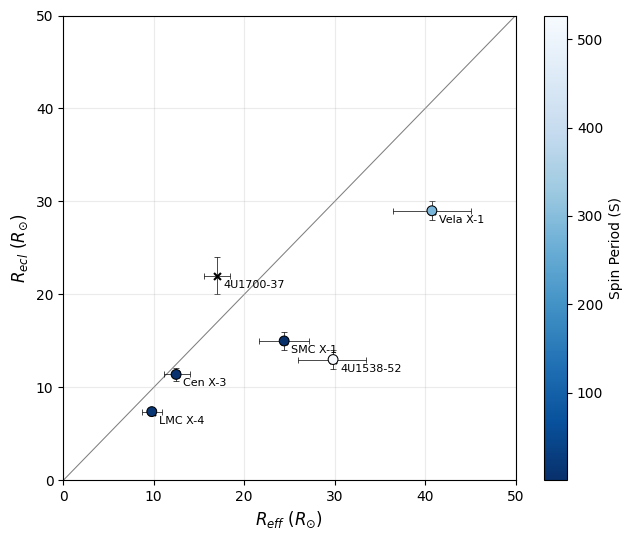

In [29]:
plt.figure(figsize=(6.5,5.5))
plt.errorbar(Reff, Recl, yerr=Recl_err, xerr=Reff_asymmetric_err, fmt='none', ecolor='black', capsize=2, zorder=1, elinewidth=.5, capthick=.5)
plt.scatter(Reff, Recl, s=25, marker='x', color='black', zorder=2)
plt.scatter(Reff, Recl, c=AllParams['Ps'].tolist(), cmap='Blues_r', edgecolors='black', linewidths=.75, s=50, zorder=3)
plt.colorbar(label='Spin Period (S)')  # Add color bar with label
plt.plot([0, 100], [0, 100], linestyle='-', color='black', alpha=.5, zorder=1, linewidth=.75)
# plt.plot([1, 1], [0,4], linestyle='-', color='black', alpha=.5, zorder=1, linewidth=.75)
# plt.scatter(1, 1, s=50, color='black', marker='D')
# Add labels to each point
for i, label in enumerate(AllParams["id"].tolist()):
    plt.annotate(label, (Reff[i], Recl[i]), textcoords="offset points", xytext=(5,-6.5), ha='left', va='center', fontsize=TEXTBOX)
plt.ylim(0, 50)
plt.xlim(0, 50)
plt.grid(True, alpha=ALPHA)
plt.xlabel(r"$R_{eff}$ $(R_{\odot})$", fontsize=LABEL)
plt.ylabel(r"$R_{ecl}$ $(R_{\odot})$", fontsize=LABEL)
plt.tight_layout()
plt.savefig(Thesis_Folder + 'RvsR.png')
plt.show()

M vs M

In [33]:
Mhrd = AllParams['Mhrd'].tolist()
Mhrd_err = AllParams['Mhrd_err'].tolist()

Mtrue = AllParams['Mopt'].tolist()
Mtrue_err = AllParams['Mopt_err'].tolist()

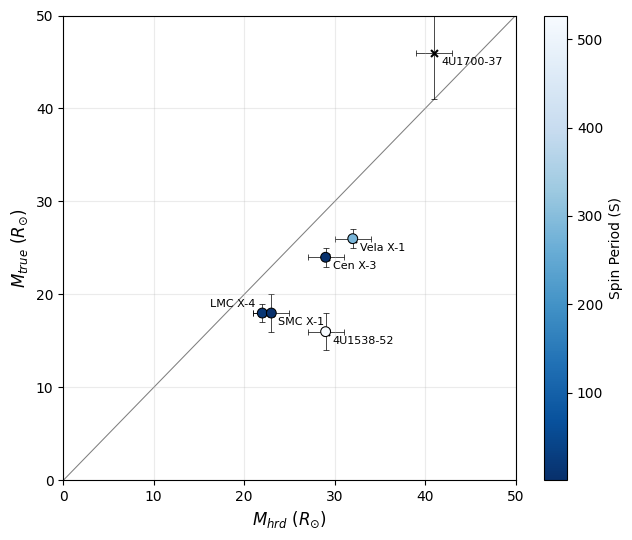

In [38]:
plt.figure(figsize=(6.5,5.5))
plt.errorbar(Mhrd, Mtrue, yerr=Mtrue_err, xerr=Mhrd_err, fmt='none', ecolor='black', capsize=2, zorder=1, elinewidth=.5, capthick=.5)
plt.scatter(Mhrd, Mtrue, s=25, marker='x', color='black', zorder=2)
plt.scatter(Mhrd, Mtrue, c=AllParams['Ps'].tolist(), cmap='Blues_r', edgecolors='black', linewidths=.75, s=50, zorder=3)
plt.colorbar(label='Spin Period (S)')  # Add color bar with label
plt.plot([0, 100], [0, 100], linestyle='-', color='black', alpha=.5, zorder=1, linewidth=.75)
# plt.plot([1, 1], [0,4], linestyle='-', color='black', alpha=.5, zorder=1, linewidth=.75)
# plt.scatter(1, 1, s=50, color='black', marker='D')
# Add labels to each point
for i, label in enumerate(AllParams["id"].tolist()):
    if label == 'LMC X-4':
        plt.annotate(label, (Mhrd[i], Mtrue[i]), textcoords="offset points", xytext=(-5,+6.5), ha='right', va='center', fontsize=TEXTBOX)
    else:
        plt.annotate(label, (Mhrd[i], Mtrue[i]), textcoords="offset points", xytext=(5,-6.5), ha='left', va='center', fontsize=TEXTBOX)
plt.ylim(0, 50)
plt.xlim(0, 50)
plt.grid(True, alpha=ALPHA)
plt.xlabel(r"$M_{hrd}$ $(R_{\odot})$", fontsize=LABEL)
plt.ylabel(r"$M_{true}$ $(R_{\odot})$", fontsize=LABEL)
plt.tight_layout()
plt.savefig(Thesis_Folder + 'MvsM.png')
plt.show()